### Imports

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error

### Introduction

##### Примеры машинного обучения в жизни:
* Распознавание спама в email
* Прогнозирование цен акций
* Диагностика заболеваний
* Прогнозирование спроса на товар 
* Распознавание лиц на фотографрях


##### Указание типов задач: 
* Прогноз цены на дом - регрессия
* Предсказать, вернет ли клиент кредит - классификация
* Предсказать, когда пациенту необходимо принять лекарство - регрессия 
* Выберите, какое лекарство из имеющихся следует принять пациенту - классификация
* Выберите сегмент клиентов для промо-коммуникации - кластеризация
* Распознавание дефектной продукции на производственной линии (на основе фотосканирования) - классификация
* Решить, как разместить товары на полке в магазине - кластеризация
* Поиск сайтов по вводу текстового запроса - ранжирование
* Разделите покупателей магазина на сегменты, чтобы понять различия в их поведении - кластеризация
* Обнаружение аномалий в трафике сайта - классицикация
* Распознавание спама в email - классификация 
* Прогнозирование цен акций - регрессия
* Диагностика заболеваний - классификация
* Прогнозирование спроса на товар - регрессия
* Распознавание лиц на фотографрях - классификация


##### Разница между multiclass и multilabel:
* multiclass: каждому образцу присваивается один класс
* multilabel: каждому образцу присвается n меток из n_classes, где n от 0 до n_classes

##### Вопросы
* Является ли пример с ценами на жильё из теории классификацией задачи регрессии? Да
* Можно ли свести задачу регрессии к классификации? Можно, разбив диапазон возможных значений на интервалы и сделав каждый полученный интервал классом

### Introduction to Data Analysis

In [25]:
data = pd.read_json('data/train.json')
data

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124000,1.0,3,92bbbf38baadfde0576fc496bd41749c,2016-04-05 03:58:33,There is 700 square feet of recently renovated...,W 171 Street,"[Elevator, Dishwasher, Hardwood Floors]",40.8433,6824800,-73.9396,a61e21da3ba18c7a3d54cfdcc247e1f8,[https://photos.renthop.com/2/6824800_0682be16...,2800,620 W 171 Street,low
124002,1.0,2,5565db9b7cba3603834c4aa6f2950960,2016-04-02 02:25:31,"2 bedroom apartment with updated kitchen, rece...",Broadway,"[Common Outdoor Space, Cats Allowed, Dogs Allo...",40.8198,6813268,-73.9578,8f90e5e10e8a2d7cf997f016d89230eb,[https://photos.renthop.com/2/6813268_1e6fcc32...,2395,3333 Broadway,medium
124004,1.0,1,67997a128056ee1ed7d046bbb856e3c7,2016-04-26 05:42:03,No Brokers Fee * Never Lived 1 Bedroom 1 Bathr...,210 Brighton 15th St,"[Dining Room, Elevator, Pre-War, Laundry in Bu...",40.5765,6927093,-73.9554,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/6927093_93a52104...,1850,210 Brighton 15th St,medium
124008,1.0,2,3c0574a740154806c18bdf1fddd3d966,2016-04-19 02:47:33,Wonderful Bright Chelsea 2 Bedroom apartment o...,West 21st Street,"[Pre-War, Laundry in Unit, Dishwasher, No Fee,...",40.7448,6892816,-74.0017,c3cd45f4381ac371507090e9ffabea80,[https://photos.renthop.com/2/6892816_1a8d087a...,4195,350 West 21st Street,medium


In [18]:
data.shape

(49352, 15)

In [19]:
data.columns

Index(['bathrooms', 'bedrooms', 'building_id', 'created', 'description',
       'display_address', 'features', 'latitude', 'listing_id', 'longitude',
       'manager_id', 'photos', 'price', 'street_address', 'interest_level'],
      dtype='object')

Target column is 'price'

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


In [21]:
data.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04
mean,1.21218,1.541640,40.741545,7.024055e+06,-73.955716,3.830174e+03
std,0.50142,1.115018,0.638535,1.262746e+05,1.177912,2.206687e+04
min,0.00000,0.000000,0.000000,6.811957e+06,-118.271000,4.300000e+01
25%,1.00000,1.000000,40.728300,6.915888e+06,-73.991700,2.500000e+03
50%,1.00000,1.000000,40.751800,7.021070e+06,-73.977900,3.150000e+03
75%,1.00000,2.000000,40.774300,7.128733e+06,-73.954800,4.100000e+03
max,10.00000,8.000000,44.883500,7.753784e+06,0.000000,4.490000e+06


In [22]:
columns = [column for column in data.columns if data[column].dtype != 'object']
numeric_data = data[columns]
numeric_data.corr()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
bathrooms,1.000000,0.533446,-0.009657,0.000776,0.010393,0.069661
bedrooms,0.533446,1.000000,-0.004745,0.011968,0.006892,0.051788
latitude,-0.009657,-0.004745,1.000000,0.001712,-0.966807,-0.000707
listing_id,0.000776,0.011968,0.001712,1.000000,-0.000907,0.008090
longitude,0.010393,0.006892,-0.966807,-0.000907,1.000000,-0.000087
price,0.069661,0.051788,-0.000707,0.008090,-0.000087,1.000000


In [26]:
features_n_target = data[['bathrooms', 'bedrooms', 'interest_level', 'price']]

<Axes: xlabel='price', ylabel='Count'>

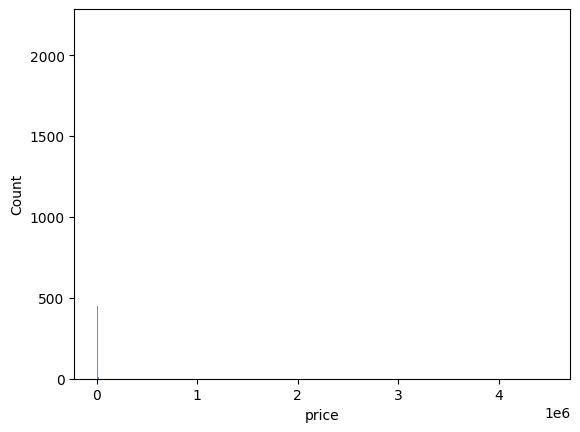

In [9]:
sns.histplot(features_n_target['price'])

<Axes: ylabel='price'>

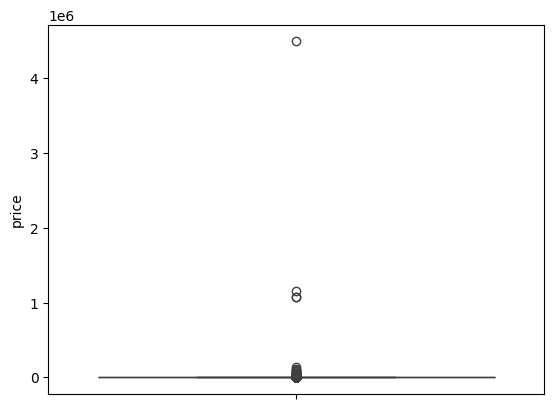

In [10]:
sns.boxplot(features_n_target['price'])

In [11]:
features_n_target['price'].sort_values(ascending=False)

32611     4490000
12168     1150000
57803     1070000
55437     1070000
123877     135000
           ...   
113599        695
85617         695
117339        401
87511          45
53144          43
Name: price, Length: 49352, dtype: int64

In [27]:
pers = np.percentile(features_n_target['price'], [99, 1])
pers

array([13000.,  1475.])

In [28]:
per_99 = features_n_target['price'].quantile(0.99)
per_1 = features_n_target['price'].quantile(0.01)
features_n_target = features_n_target[(features_n_target['price'] < per_99) & (features_n_target['price'] > per_1)]

In [14]:
features_n_target.sort_values('price')

,bathrooms,bedrooms,interest_level,price
73009,1.0,0,high,1485
63217,1.0,1,medium,1489
63261,1.0,1,high,1489
88,1.0,0,high,1495
88873,1.0,0,high,1495
...,...,...,...,...
70141,3.5,3,low,12995
36953,3.0,4,low,12995
74202,4.0,3,low,12995
113036,4.0,3,low,12995


<Axes: xlabel='price', ylabel='Count'>

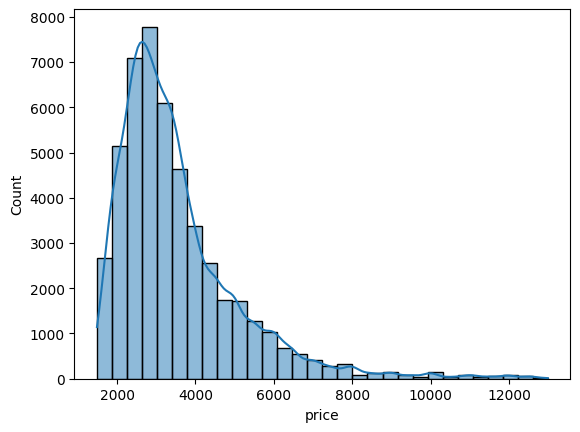

In [15]:
sns.histplot(features_n_target['price'], bins=30, kde=True)

<Axes: ylabel='price'>

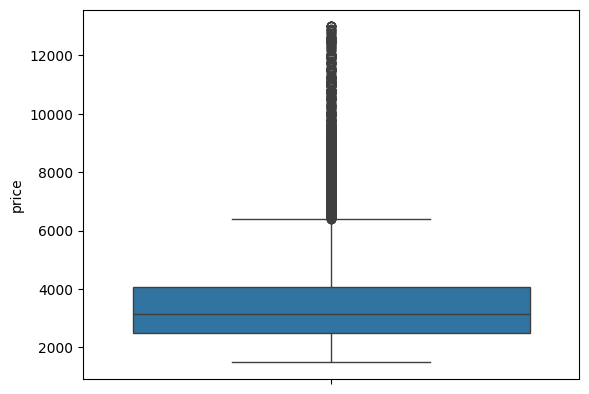

In [16]:
sns.boxplot(features_n_target['price'])

### Characteristics Analysis
* What is the type of column 'interest_level'?
* Print the values in this column. How many entries does each value contain?
* Encode these values. For example, you can replace each value with 0, 1, or 2.
* Plot histograms for the features 'bathrooms', 'bedrooms'. Are there any outliers?

In [704]:
features_n_target['interest_level'].dtype

dtype('O')

In [705]:
features_n_target['interest_level'].info()

<class 'pandas.core.series.Series'>
Index: 48343 entries, 4 to 124009
Series name: interest_level
Non-Null Count  Dtype 
--------------  ----- 
48343 non-null  object
dtypes: object(1)
memory usage: 755.4+ KB


In [29]:
features_n_target[features_n_target['interest_level'] == 'medium'].count()

bathrooms         11114
bedrooms          11114
interest_level    11114
price             11114
dtype: int64

In [30]:
features_n_target[features_n_target['interest_level'] == 'high'].count()

bathrooms         3557
bedrooms          3557
interest_level    3557
price             3557
dtype: int64

In [31]:
features_n_target[features_n_target['interest_level'] == 'low'].count()

bathrooms         33672
bedrooms          33672
interest_level    33672
price             33672
dtype: int64

In [706]:
features_n_target['interest_level']

4         medium
6            low
9         medium
10        medium
15           low
           ...  
124000       low
124002    medium
124004    medium
124008    medium
124009      high
Name: interest_level, Length: 48343, dtype: object

In [35]:
features_n_target['interest_level'] = features_n_target['interest_level'].astype('category').cat.rename_categories(new_categories={'high': 2, 'medium': 1, 'low': 0})
features_n_target['interest_level'] 

4         1
6         0
9         1
10        1
15        0
         ..
124000    0
124002    1
124004    1
124008    1
124009    2
Name: interest_level, Length: 48343, dtype: category
Categories (3, int64): [2, 0, 1]

<Axes: xlabel='bathrooms', ylabel='Count'>

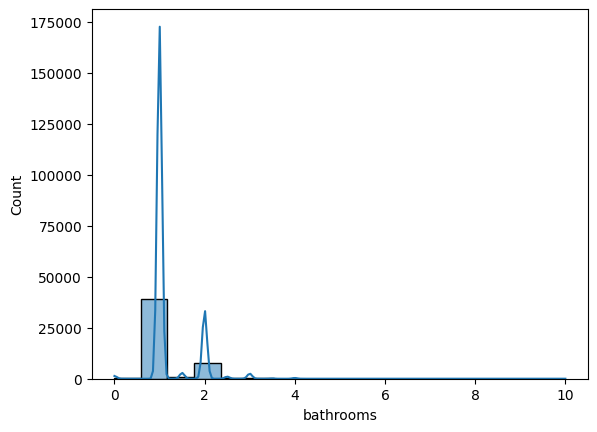

In [708]:
sns.histplot(features_n_target['bathrooms'], kde=True)

<Axes: xlabel='bedrooms', ylabel='Count'>

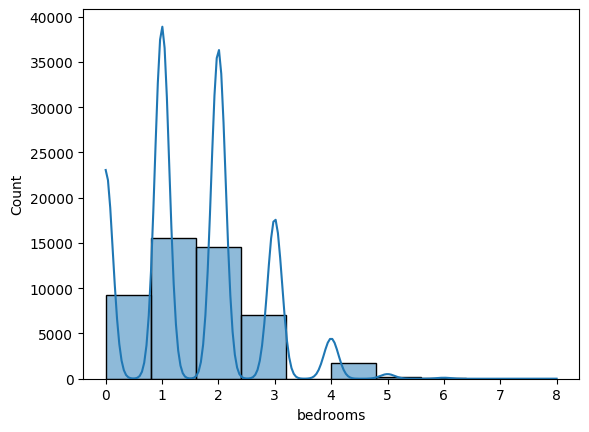

In [32]:
sns.histplot(features_n_target['bedrooms'], bins=10, kde=True)

### Complex analysis
* Plot a correlation matrix to understand the correlation between features and target. Plot a heat map for the correlation matrix. Is there a correlation?
* Plot a scatterplot to visualize the correlation between the features and the target. You should return 3 plots where the X-axis is the target and the Y-axis is a feature.

In [36]:
correlation_matrix = features_n_target.corr()
correlation_matrix

,bathrooms,bedrooms,interest_level,price
bathrooms,1.000000,0.517200,-0.062819,0.670808
bedrooms,0.517200,1.000000,0.051282,0.547310
interest_level,-0.062819,0.051282,1.000000,-0.199652
price,0.670808,0.547310,-0.199652,1.000000


<Axes: xlabel='price', ylabel='bathrooms'>

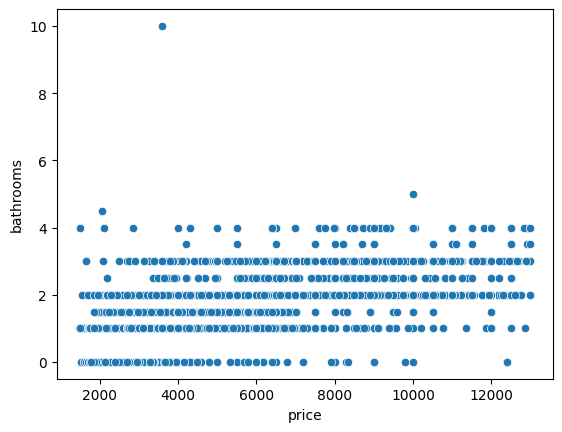

In [ ]:
sns.scatterplot(data=features_n_target, x='price', y='bathrooms')

<Axes: xlabel='price', ylabel='bedrooms'>

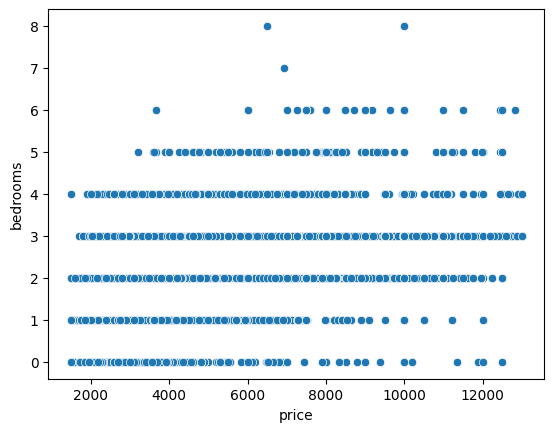

In [ ]:
sns.scatterplot(data=features_n_target, x='price', y='bedrooms')

In [ ]:
features_n_target['interest_level'] = features_n_target['interest_level'].astype(int)

<Axes: xlabel='price', ylabel='interest_level'>

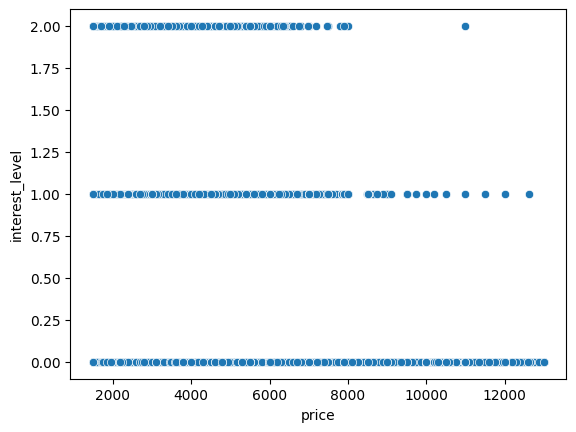

In [ ]:
sns.scatterplot(data=features_n_target, x='price', y='interest_level')

### Creating Features
* This step is very broad. You can create as many features as you want. For example, you can add 3 new features that are squared: 'bathrooms_squared', 'bedrooms_squared', ''interest_level_squared'. Plot a correlation matrix with the new features. Are the new features more correlated with the target than the basic features?
* To train the model here, we will not use your new features. Remember this example and use it in Lecture 2. To train the model, we will only consider the features 'bathrooms' and 'bedrooms'.
* Read this Sklearn info about PolynomialFeatures
* To use PolynomialFeatures, we first need to split the data into training and test samples. We have already done this for you, please read the training and test data
* Initialize PolynomialFeatures() with a degree of 10
* Apply PolynomialFeatures() to fit and transform your training and test data

In [ ]:
features_n_target['bathrooms_squared'] = features_n_target['bathrooms'] * features_n_target['bathrooms']
features_n_target['bedrooms_squared'] = features_n_target['bedrooms'] * features_n_target['bedrooms']
features_n_target['interest_level_squared'] = features_n_target['interest_level'] * features_n_target['interest_level']

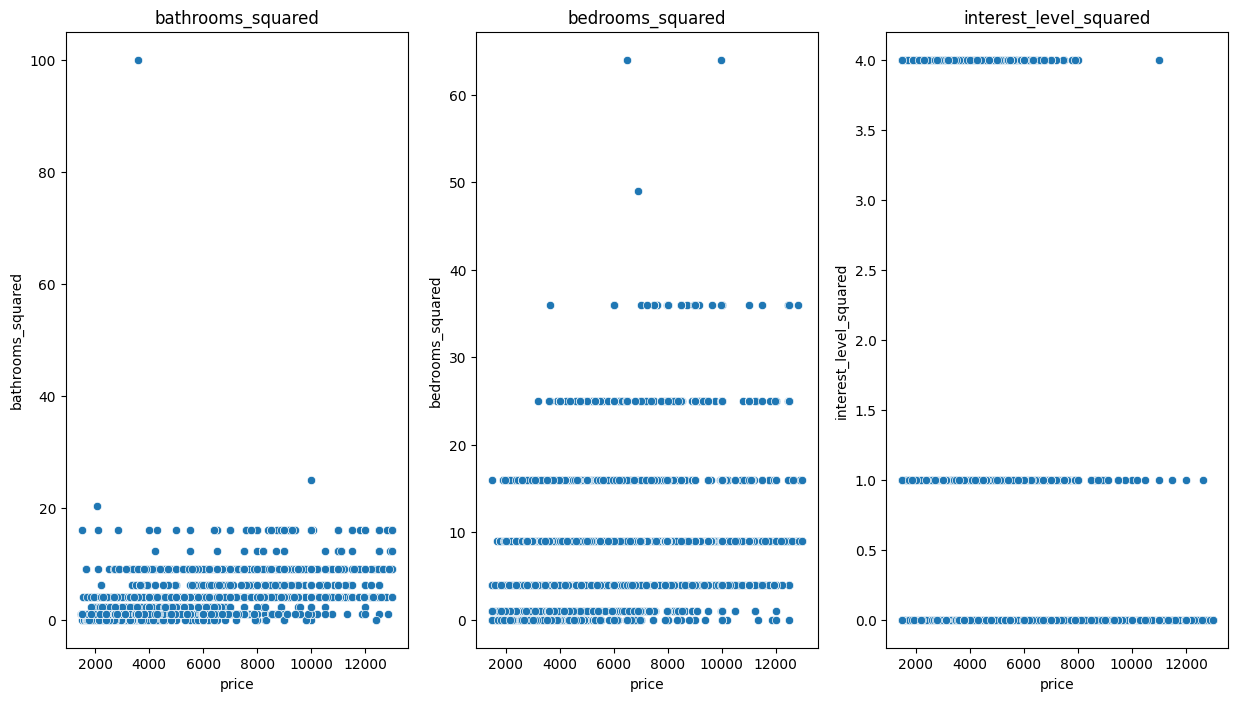

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 8))

sns.scatterplot(data=features_n_target, x='price', y='bathrooms_squared', ax=axes[0])
axes[0].set_title('bathrooms_squared')

sns.scatterplot(data=features_n_target, x='price', y='bedrooms_squared', ax=axes[1])
axes[1].set_title('bedrooms_squared')

sns.scatterplot(data=features_n_target, x='price', y='interest_level_squared', ax=axes[2])
axes[2].set_title('interest_level_squared')

plt.show()

In [ ]:
features_n_target.corr()

,bathrooms,bedrooms,interest_level,price,bathrooms_squared,bedrooms_squared,interest_level_squared
bathrooms,1.000000,0.517200,-0.062819,0.670808,0.955906,0.548426,-0.058710
bedrooms,0.517200,1.000000,0.051282,0.547310,0.478497,0.928282,0.040125
interest_level,-0.062819,0.051282,1.000000,-0.199652,-0.067757,0.047048,0.943959
price,0.670808,0.547310,-0.199652,1.000000,0.646949,0.544612,-0.182283
bathrooms_squared,0.955906,0.478497,-0.067757,0.646949,1.000000,0.521951,-0.061563
bedrooms_squared,0.548426,0.928282,0.047048,0.544612,0.521951,1.000000,0.036408
interest_level_squared,-0.058710,0.040125,0.943959,-0.182283,-0.061563,0.036408,1.000000


In [ ]:
test_part = pd.read_json('data/test.json')

In [ ]:
per_99 = test_part['price'].quantile(0.99)
per_1 = test_part['price'].quantile(0.01)
test_part = test_part[(test_part['price'] < per_99) & (test_part['price'] > per_1)]

In [ ]:
per_99 = test_part['bedrooms'].quantile(0.99)
per_1 = test_part['bedrooms'].quantile(0.01)
test_part = test_part[(test_part['bedrooms'] < per_99) & (test_part['bedrooms'] > per_1)]

In [ ]:
per_99 = test_part['bathrooms'].quantile(0.99)
per_1 = test_part['bathrooms'].quantile(0.01)
test_part = test_part[(test_part['bathrooms'] < per_99) & (test_part['bathrooms'] > per_1)]

In [ ]:
X_train = features_n_target[['bathrooms', 'bedrooms']]
y_train = features_n_target['price']

X_test = test_part[['bathrooms', 'bedrooms']]
y_test = test_part['price']

In [ ]:
poly = PolynomialFeatures(degree=10)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

In [ ]:
result_MAE = pd.DataFrame(columns=['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns=['model', 'train', 'test'])

### Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
LinReg = LinearRegression()
LinReg.fit(X_poly_train, y_train)

y_pred_train = LinReg.predict(X_poly_train)
y_pred_test = LinReg.predict(X_poly_test)

In [ ]:
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

result_MAE = pd.concat([result_MAE, pd.DataFrame({'model': ['linear_regression'], 'train': [mae_train], 'test': [mae_test]})], ignore_index=True)
result_RMSE = pd.concat([result_RMSE, pd.DataFrame({'model': ['linear_regression'], 'train': [rmse_train], 'test': [rmse_test]})], ignore_index=True)


/var/folders/jb/zkfyxcwx1_z7_qyw8llwwzxw0000gn/T/ipykernel_59137/176846310.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_MAE = pd.concat([result_MAE, pd.DataFrame({'model': ['linear_regression'], 'train': [mae_train], 'test': [mae_test]})], ignore_index=True)
/var/folders/jb/zkfyxcwx1_z7_qyw8llwwzxw0000gn/T/ipykernel_59137/176846310.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_RMSE = pd.concat([result_RMSE, pd.DataFrame({'model': ['linear_regression'], 'train': [rmse_t

In [ ]:
result_MAE

,model,train,test
0,linear_regression,753.679394,1238.906884


In [ ]:
result_RMSE

,model,train,test
0,linear_regression,1070.669027,1674.013594


### Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=21)
tree.fit(X_poly_train, y_train)

y_pred_train = tree.predict(X_poly_train)
y_pred_test = tree.predict(X_poly_test)



In [ ]:
features_n_target

,bathrooms,bedrooms,interest_level,price,bathrooms_squared,bedrooms_squared,interest_level_squared
4,1.0,1,1,2400,1.00,1,1
6,1.0,2,0,3800,1.00,4,0
9,1.0,2,1,3495,1.00,4,1
10,1.5,3,1,3000,2.25,9,1
15,1.0,0,0,2795,1.00,0,0
...,...,...,...,...,...,...,...
124000,1.0,3,0,2800,1.00,9,0
124002,1.0,2,1,2395,1.00,4,1
124004,1.0,1,1,1850,1.00,1,1
124008,1.0,2,1,4195,1.00,4,1


In [ ]:
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

result_MAE = pd.concat([result_MAE, pd.DataFrame({'model': 'decision_tree', 'train': [mae_train], 'test': [mae_test]})], ignore_index=True)
result_RMSE = pd.concat([result_RMSE, pd.DataFrame({'model': ['decision_tree'], 'train': [rmse_train], 'test': [rmse_test]})], ignore_index=True)


In [ ]:
result_RMSE

,model,train,test
0,linear_regression,1070.669027,1674.013594
1,decision_tree,1070.598967,1675.013839


### Naive Models

In [ ]:
features_n_target['price']

4         2400
6         3800
9         3495
10        3000
15        2795
          ... 
124000    2800
124002    2395
124004    1850
124008    4195
124009    4280
Name: price, Length: 48343, dtype: int64

In [ ]:
features_n_target['mean'] = features_n_target['price'].mean()
features_n_target['median'] = features_n_target['price'].median()

test_part['mean'] = test_part['price'].mean()
test_part['median'] = features_n_target['price'].median()

In [ ]:
mean_mae_train = mean_absolute_error(features_n_target['mean'], features_n_target['price'])
mean_mae_test = mean_absolute_error(test_part['mean'], test_part['price'])
median_mae_train = mean_absolute_error(features_n_target['median'], features_n_target['price'])
median_mae_test = mean_absolute_error(test_part['median'], test_part['price'])

mean_rmse_train = np.sqrt(mean_squared_error(features_n_target['mean'], features_n_target['price']))
mean_rmse_test = np.sqrt(mean_squared_error(test_part['mean'], test_part['price']))
median_rmse_train = np.sqrt(mean_squared_error(features_n_target['median'], features_n_target['price']))
median_rmse_test = np.sqrt(mean_squared_error(test_part['median'], test_part['price']))




In [ ]:
result_MAE = pd.concat([result_MAE, pd.DataFrame({'model': ['naive_mean'], 'train': [mean_mae_train], 'test': [mean_mae_test]})], ignore_index=True)
result_RMSE = pd.concat([result_RMSE, pd.DataFrame({'model': ['naive_mean'], 'train': [mean_rmse_train], 'test': [mean_rmse_test]})], ignore_index=True)

result_MAE = pd.concat([result_MAE, pd.DataFrame({'model': ['naive_median'], 'train': [median_mae_train], 'test': [median_mae_test]})], ignore_index=True)
result_RMSE = pd.concat([result_RMSE, pd.DataFrame({'model': ['naive_median'], 'train': [median_rmse_train], 'test': [median_rmse_test]})], ignore_index=True)

### Results

In [ ]:
result_MAE

,model,train,test
0,linear_regression,753.679394,1238.906884
1,decision_tree,753.675997,1239.596640
2,naive_mean,1134.361473,1301.344643
3,naive_median,1082.220859,2182.549501


In [ ]:
result_RMSE

,model,train,test
0,linear_regression,1070.669027,1674.013594
1,decision_tree,1070.598967,1675.013839
2,naive_mean,1585.609099,1762.433196
3,naive_median,1631.719953,2728.386450
